In [1]:
!pip install seaborn

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv(r"C:\Users\Kalyan\OneDrive\Desktop\Wine.csv",usecols=[0,1,13])
#using 0,1,13 cols only

In [ ]:
df.describe()
#describes the data

,Alcohol,Malic_Acid,Customer_Segment
count,178.000000,178.000000,178.000000
mean,13.000618,2.336348,1.938202
std,0.811827,1.117146,0.775035
min,11.030000,0.740000,1.000000
25%,12.362500,1.602500,1.000000
50%,13.050000,1.865000,2.000000
75%,13.677500,3.082500,3.000000
max,14.830000,5.800000,3.000000


<AxesSubplot:xlabel='Alcohol', ylabel='Count'>

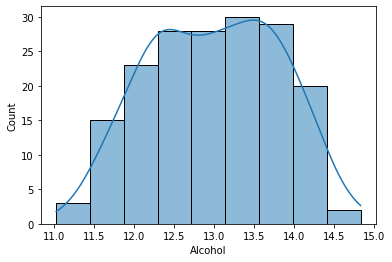

In [ ]:
#histplot for Alcohol with kdeplot
sns.histplot(df["Alcohol"],kde=True)


<AxesSubplot:xlabel='Alcohol', ylabel='Density'>

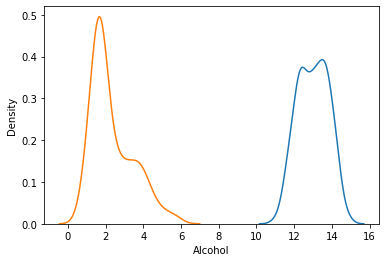

In [ ]:
#kdeplot for both Alcohol and Malic_Acid
sns.kdeplot(df["Alcohol"])
sns.kdeplot(df["Malic_Acid"])

<AxesSubplot:xlabel='Malic_Acid', ylabel='Count'>

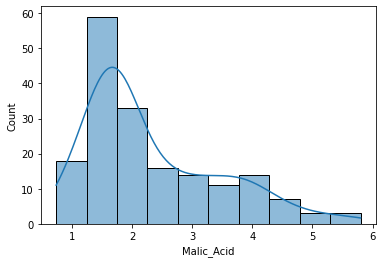

In [ ]:
#Histplot forMalic_Acid
sns.histplot(df["Malic_Acid"],kde=True)

<AxesSubplot:xlabel='Alcohol', ylabel='Malic_Acid'>

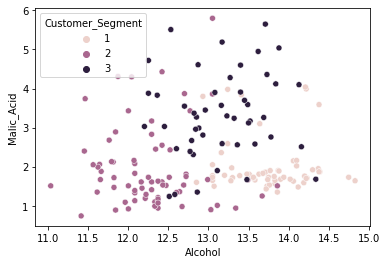

In [ ]:
#scatter plot without color palette
sns.scatterplot(x=df["Alcohol"],y=df["Malic_Acid"], hue= df["Customer_Segment"])

<AxesSubplot:xlabel='Alcohol', ylabel='Malic_Acid'>

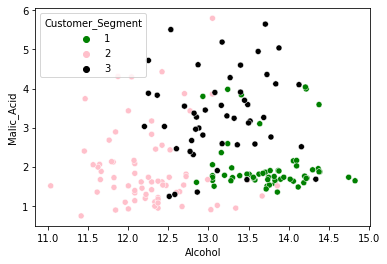

In [ ]:
#scatter plot with color plaette
sns.scatterplot(x=df["Alcohol"],y=df["Malic_Acid"], hue=df["Customer_Segment"],
                palette={1:"green",2:"pink",3:"black"})

In [ ]:
#importing scikit-learn models for training and testing the data
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(df.drop("Customer_Segment",axis=1),df['Customer_Segment'],
                                               test_size=0.20,
                                               random_state=2)


In [11]:
x_train.shape

(142, 2)

In [12]:
y_train.shape

(142,)

In [13]:
x_test.shape

(36, 2)

In [14]:
y_test.shape


(36,)

In [ ]:
#importing MinMaxScaler to find minmum and maximum data
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
scaler.fit(x_train)


MinMaxScaler()

In [16]:
x_train_normalised=scaler.transform(x_train)
x_test_normalised=scaler.transform(x_test)

In [17]:
# x_test.describe()

In [18]:
x_train_normalised=pd.DataFrame(x_train_normalised)
x_train_normalised.columns = x_train.columns
x_train_normalised.describe()

,Alcohol,Malic_Acid
count,142.000000,142.000000
mean,0.506042,0.298701
std,0.208965,0.237139
min,0.000000,0.000000
25%,0.342763,0.130346
50%,0.521053,0.189409
75%,0.678947,0.461813
max,1.000000,1.000000


In [19]:
x_test_normalised=pd.DataFrame(x_test_normalised)
x_test_normalised.columns=x_test.columns
x_test_normalised.columns
x_test_normalised.describe()

,Alcohol,Malic_Acid
count,36.000000,36.000000
mean,0.568056,0.278287
std,0.227480,0.186836
min,0.100000,-0.030550
25%,0.371711,0.168534
50%,0.569737,0.205703
75%,0.748026,0.372200
max,0.978947,0.720978


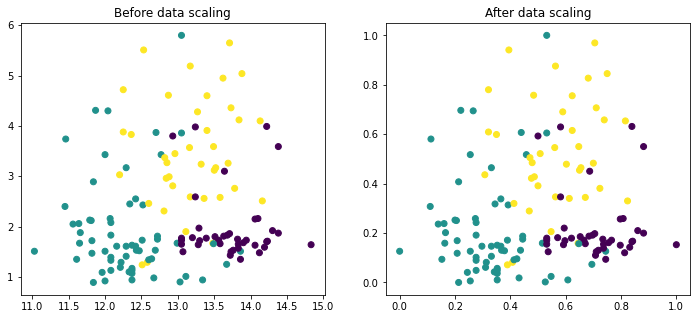

In [20]:
fig, (sub_fig1,sub_fig2)=plt.subplots(nrows=1,ncols=2,figsize=(12,5))
sub_fig1.set_title("Before data scaling")
sub_fig1.scatter(x_train["Alcohol"],x_train["Malic_Acid"],c=y_train)
sub_fig2.set_title("After data scaling")
sub_fig2.scatter(x_train_normalised["Alcohol"],x_train_normalised["Malic_Acid"],c=y_train)

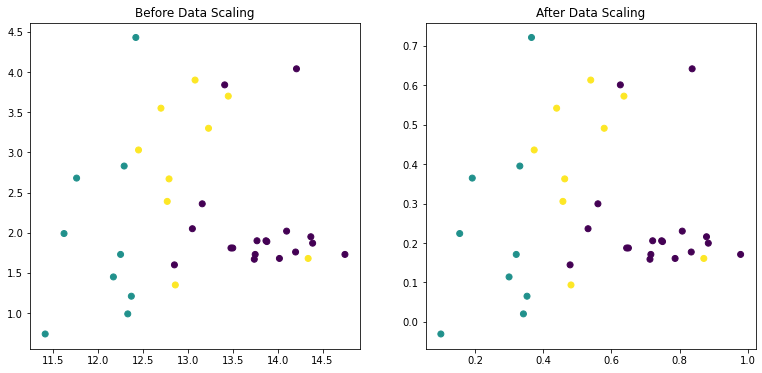

In [21]:
fig, (sub_fig1,sub_fig2) = plt.subplots(nrows=1,ncols=2,figsize=(13,6))
sub_fig1.set_title("Before Data Scaling")
sub_fig2.set_title("After Data Scaling")
sub_fig1.scatter(x_test["Alcohol"],x_test["Malic_Acid"],c=y_test)
sub_fig2.scatter(x_test_normalised["Alcohol"],x_test_normalised["Malic_Acid"],c=y_test)
plt.show()

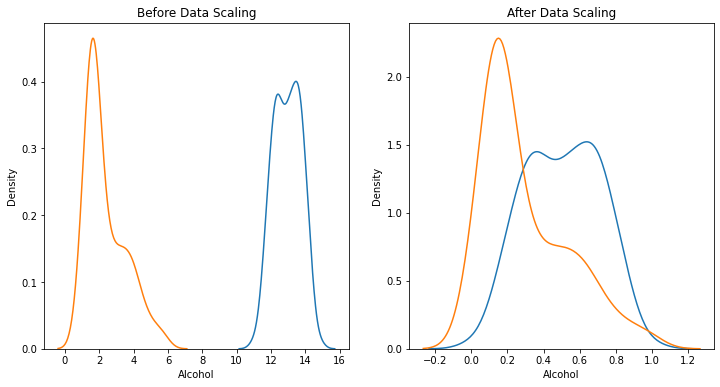

In [22]:
fig, (sub_fig1,sub_fig2) = plt.subplots(nrows=1,ncols=2,figsize=(12,6))
sub_fig1.set_title("Before Data Scaling")
sns.kdeplot(x_train["Alcohol"],ax=sub_fig1)
sns.kdeplot(x_train["Malic_Acid"],ax=sub_fig1)
sub_fig2.set_title("After Data Scaling")
sns.kdeplot(x_train_normalised["Alcohol"],ax=sub_fig2)
sns.kdeplot(x_train_normalised["Malic_Acid"],ax=sub_fig2)
plt.show()

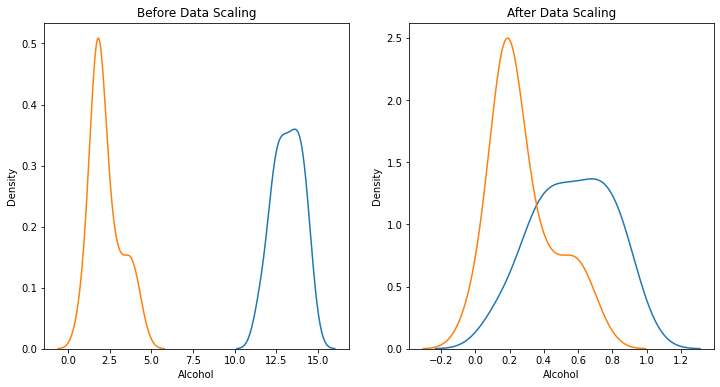

In [23]:
fig, (sub_fig1,sub_fig2) = plt.subplots(nrows = 1, ncols = 2, figsize = (12,6))
sub_fig1.set_title("Before Data Scaling")
sns.kdeplot(x_test["Alcohol"], ax=sub_fig1)
sns.kdeplot(x_test["Malic_Acid"], ax=sub_fig1)
sub_fig2.set_title("After Data Scaling")
sns.kdeplot(x_test_normalised["Alcohol"], ax=sub_fig2)
sns.kdeplot(x_test_normalised["Malic_Acid"],ax=sub_fig2)
plt.show()